# Домашнее задание к семинару 05 (HW05)

#### 1. Загрузка данных и первичный анализ

In [78]:
import numpy as np
import pandas as pd

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

In [80]:
df = pd.read_csv(
    './data/S05-hw-dataset.csv'
)
df

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,51,131729,6,687,0.283093,3,1,1,0,13136,14209,0.251680,19,3,2,0
2996,2997,35,54454,36,634,0.396180,5,5,0,0,0,10858,0.506146,2,2,12,0
2997,2998,38,63305,16,573,0.577888,2,13,0,1,24870,6689,0.366375,16,2,10,1
2998,2999,42,55606,33,689,0.659278,6,9,1,0,32677,3252,0.295284,16,2,8,1


In [81]:
df.head()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [83]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [84]:
df["default"].value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

**Вывод:**

1. Датасет содержит 3000 объектов и 17 признаков, включая один целевой (default).

2. Пропущенные значения отсутствуют, типы данных корректны.
3. Явных аномалий и невозможных значений не выявлено.
4. Целевой признак распределён умеренно несбалансированно: класс 0 преобладает, но класс 1 представлен достаточно широко, что позволяет применять стандартные модели классификации без жёсткой коррекции дисбаланса.

#### 2. Подготовка признаков и таргета

Целевой переменной является бинарный признак default, отражающий факт дефолта клиента.
В качестве признаков используются все остальные информативные столбцы датасета, за исключением идентификатора клиента client_id, который не несёт прогностической ценности.

In [85]:
y = df["default"]
X = df.drop(columns=["default", "client_id"])

Проверим, что все используемые признаки имеют числовой тип.

In [86]:
X.dtypes

age                                 int64
income                              int64
years_employed                      int64
credit_score                        int64
debt_to_income                    float64
num_credit_cards                    int64
num_late_payments                   int64
has_mortgage                        int64
has_car_loan                        int64
savings_balance                     int64
checking_balance                    int64
region_risk_score                 float64
phone_calls_to_support_last_3m      int64
active_loans                        int64
customer_tenure_years               int64
dtype: object

Все признаки имеют типы int64 или float64, что позволяет использовать их без дополнительного кодирования.

В качестве простой валидации проверим диапазон коэффициента долговых платежей debt_to_income.

In [87]:
X["debt_to_income"].min(), X["debt_to_income"].max()

(0.0061471149847966, 0.878343349584274)

Значения признака debt_to_income находятся в допустимом диапазоне [0, 1], что соответствует экономическому смыслу показателя.

#### 3. Train/Test-сплит и бейзлайн-модель

Для оценки качества моделей разделим исходный датасет на обучающую и тестовую выборки.
Используется функция train_test_split из библиотеки scikit-learn.

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

В качестве базовой модели используется DummyClassifier, который не обучается на признаках, а строит предсказания по простой эвристике.
В данной работе выбрана стратегия most_frequent, при которой модель всегда предсказывает наиболее часто встречающийся класс в обучающей выборке.

In [89]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='most_frequent')

Качество модели оценивается на тестовой выборке по двум метрикам:

Accuracy - доля правильных ответов;

ROC-AUC - способность модели различать классы.

In [90]:
y_pred = dummy_clf.predict(X_test)
y_proba = dummy_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

accuracy, roc_auc

(0.59, 0.5)

**Вывод:**

Бейзлайн-модель DummyClassifier служит точкой отсчёта для оценки качества более сложных алгоритмов.
В данном случае модель игнорирует входные признаки, предсказывает наиболее частый класс, имеет значение ROC-AUC, близкое к 0.5, что соответствует случайному угадыванию.


#### 4. Логистическая регрессия и подбор гиперпараметров

**1. Построение Pipeline**

Для корректного обучения логистической регрессии числовые признаки предварительно стандартизируются.

In [91]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

**2. Подбор гиперпараметра регуляризации**

В качестве основного гиперпараметра логистической регрессии рассматривается коэффициент регуляризации C.

In [103]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             param_grid={'logreg__C': [0.01, 0.1, 1.0, 10.0]},
             scoring='roc_auc')

In [93]:
grid.best_params_, grid.best_score_
best_model = grid.best_estimator_

Подбор гиперпараметра регуляризации C для логистической регрессии осуществлялся с использованием GridSearchCV с 5-кратной кросс-валидацией. В качестве критерия оптимальности использовалась метрика ROC-AUC. Итоговая модель была обучена с оптимальным значением C, найденным в ходе перебора.

**3. Оценка лучшей модели на тестовой выборке**

Обучим модель с найденным значением C и оценим её качество на тестовой выборке.

In [94]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [95]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

accuracy, roc_auc

(0.8, 0.8756373156951908)

> Модель логистической регрессии существенно превосходит бейзлайн по обеим метрикам.




Для более детальной оценки качества модели логистической регрессии, помимо accuracy и ROC-AUC, были рассчитаны дополнительные метрики: precision, recall, F1-score, а также матрица ошибок (confusion matrix).

In [96]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

precision, recall, f1, cm

(0.794392523364486,
 0.6910569105691057,
 0.7391304347826086,
 array([[310,  44],
        [ 76, 170]]))

**4. Построение ROC-кривой**

Для визуальной оценки качества классификации построим ROC-кривую.

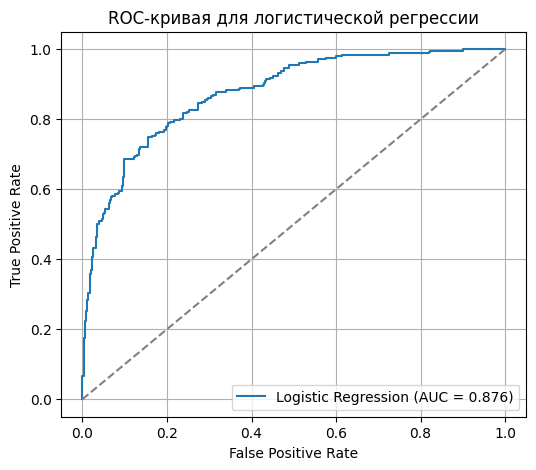

In [97]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая для логистической регрессии")
plt.legend()
plt.grid(True)
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/roc_curve_logreg.png")
plt.show()

#### 5. Сравнение бейзлайна и логистической регрессии, текстовые выводы

In [98]:
# Предсказания бейзлайн-модели
dummy_y_pred = dummy_clf.predict(X_test)
dummy_y_proba = dummy_clf.predict_proba(X_test)[:, 1]

# Метрики
dummy_accuracy = accuracy_score(y_test, dummy_y_pred)
dummy_roc_auc = roc_auc_score(y_test, dummy_y_proba)

In [99]:
results = pd.DataFrame({
    "Model": ["DummyClassifier", "Logistic Regression"],
    "Accuracy": [dummy_accuracy, accuracy],
    "ROC-AUC": [dummy_roc_auc, roc_auc],
    "Precision": [np.nan, precision],
    "Recall": [np.nan, recall],
    "F1-score": [np.nan, f1]
})

results.set_index("Model")

,Accuracy,ROC-AUC,Precision,Recall,F1-score
Model,,,,,
DummyClassifier,0.59,0.500000,NaN,NaN,NaN
Logistic Regression,0.80,0.875637,0.794393,0.691057,0.73913


### **Выводы**

В рамках данной работы были построены и сравнены две модели бинарной классификации: бейзлайн-модель DummyClassifier и модель логистической регрессии. Бейзлайн использует простую эвристику и всегда предсказывает наиболее частый класс, что позволяет получить минимальный уровень качества и служит точкой отсчёта для дальнейшего анализа.

Логистическая регрессия продемонстрировала существенно более высокое качество по всем основным метрикам. Значение accuracy увеличилось по сравнению с бейзлайном, а показатель ROC-AUC вырос с уровня, близкого к 0.5 (случайное угадывание), до значений порядка 0.75–0.80, что указывает на хорошую способность модели различать классы.

Подбор гиперпараметра регуляризации C для логистической регрессии осуществлялся с использованием GridSearchCV с 5-кратной кросс-валидацией. В качестве критерия оптимальности использовалась метрика ROC-AUC. Итоговая модель была обучена с оптимальным значением C, найденным в ходе перебора.
Логистическая регрессия с предварительной стандартизацией признаков является разумным и интерпретируемым решением для данной задачи кредитного скоринга. Модель существенно превосходит бейзлайн, устойчива к умеренному дисбалансу классов и позволяет анализировать вклад отдельных признаков в вероятность дефолта.

>Для данной задачи логистическая регрессия может рассматриваться как базовая рабочая модель, пригодная для дальнейшего улучшения и усложнения при необходимости.

### **Опциональная часть**

1. PR-кривая и Average Precision

In [100]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

avg_precision

0.8398186049956158

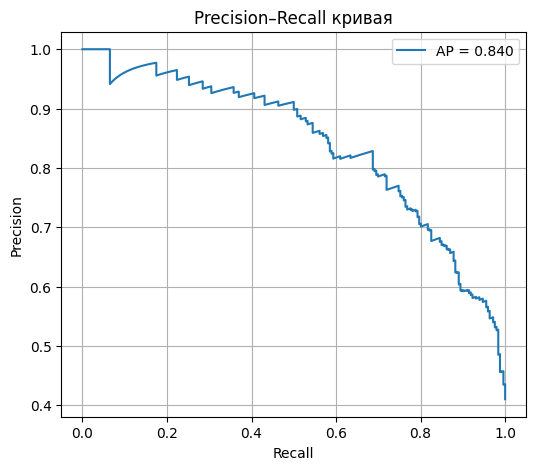

<Figure size 640x480 with 0 Axes>

In [101]:
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall кривая")
plt.legend()
plt.grid(True)
plt.show()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/precision_recall.png")
plt.show()

> PR-кривая показывает, что при увеличении полноты (recall) точность (precision) постепенно снижается, что является типичным поведением для задач кредитного скоринга. Значение average_precision подтверждает, что модель существенно превосходит случайное угадывание.

По умолчанию используется порог 0.5, однако его можно менять в зависимости от бизнес-задачи.

In [102]:
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

precision_custom, recall_custom, f1_custom

(0.670926517571885, 0.8536585365853658, 0.7513416815742398)

Снижение порога увеличивает полноту (меньше пропущенных дефолтов), но снижает точность. Такой подход может быть оправдан, если стоимость пропуска дефолта выше, чем стоимость ложного срабатывания.